In [2]:
import networkx as nx
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt

#[Label Propagation](https://pubmed.ncbi.nlm.nih.gov/17930305/)

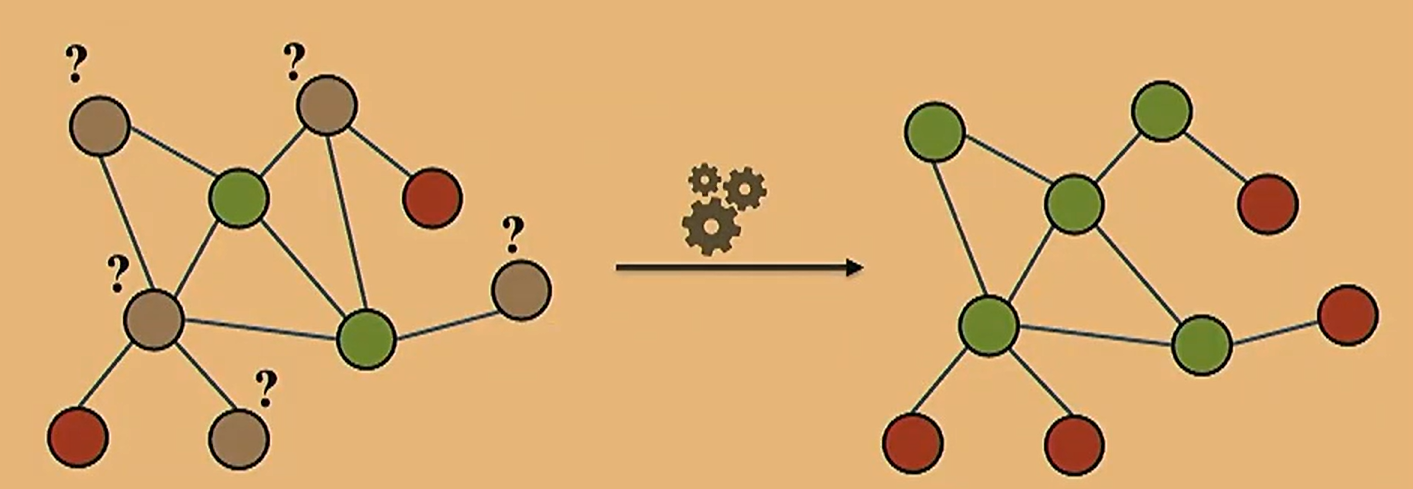

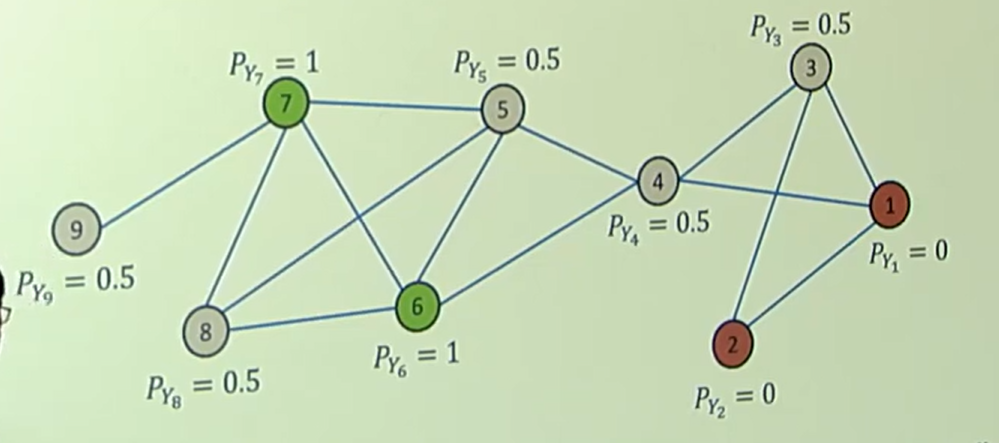

In [25]:
#Generamos datos con Stochastic Block Model
tamaños_comunidades = [15, 15, 15]
matriz_probabilidades = [
    [0.80, 0.05, 0.05],
    [0.05, 0.80, 0.05],
    [0.05, 0.05, 0.80]
]

G = nx.stochastic_block_model(tamaños_comunidades, matriz_probabilidades, seed=42)
posiciones = nx.spring_layout(G, seed=42)
print(f"La red tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} enlaces.")

La red tiene 45 nodos y 268 enlaces.


[Near linear time algorithm to detect community structures in large-scale networks](https://journals.aps.org/pre/pdf/10.1103/PhysRevE.76.036106)

In [39]:
#Label propagation dede 0
def lpa_desde_cero(grafo, max_iter=100):
    """
    Usamos actualización asincrónica, ¿por qué? Pues si todos se actualizan al mismo tiempo,
    un grafo bipartito intercambiaría colores infinitamente sin converger.
    """
    #Cada nodo recibe una etiqueta única (su propio ID).
    etiquetas = {nodo: nodo for nodo in grafo.nodes()}
    nodos_lista = list(grafo.nodes())

    for iteracion in range(max_iter):
        etiquetas_cambiaron = False
        #Mezclamos el orden de los nodos en cada iteración
        random.shuffle(nodos_lista)
        for nodo in nodos_lista:
            vecinos = list(grafo.neighbors(nodo))
            if not vecinos:
                continue

            #Recopilamos las etiquetas actuales de los vecinos
            etiquetas_vecinos = [etiquetas[vecino] for vecino in vecinos]
            #Contamos las frecuencias
            conteo = Counter(etiquetas_vecinos)
            frecuencia_maxima = max(conteo.values())
            #Obtenemos todas las etiquetas que empatan con la frecuencia máxima
            mejores_etiquetas = [etq for etq, frec in conteo.items() if frec == frecuencia_maxima]
            #Rompemos empates aleatoriamente
            nueva_etiqueta = random.choice(mejores_etiquetas)

            if etiquetas[nodo] != nueva_etiqueta:
                etiquetas[nodo] = nueva_etiqueta
                etiquetas_cambiaron = True

        #Convergencia: Si nadie cambió de opinión, terminamos.
        if not etiquetas_cambiaron:
            print(f"Label Propagation convergió en {iteracion + 1} iteraciones.")
            break

    #Agrupamos los nodos por su etiqueta final.
    comunidades_dict = {}
    for nodo, etiqueta in etiquetas.items():
        if etiqueta not in comunidades_dict:
            comunidades_dict[etiqueta] = set()
        comunidades_dict[etiqueta].add(nodo)

    return list(comunidades_dict.values())

comunidades_propias = lpa_desde_cero(G)

Label Propagation convergió en 3 iteraciones.


In [38]:
#Label propagation de networkX
comunidades_nx = list(nx.community.asyn_lpa_communities(G, weight=None, seed=42))
comunidades_nx

[{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14},
 {15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29},
 {30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44}]

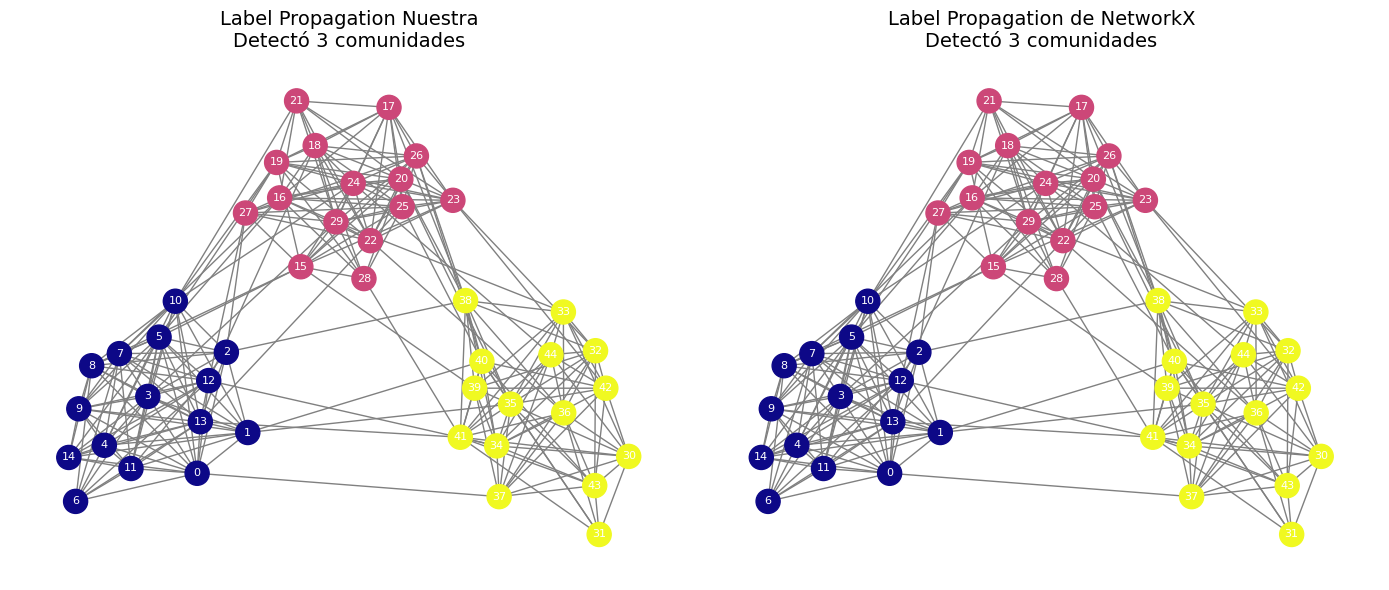

In [43]:
def asignar_colores(comunidades, total_nodos):
    mapa_colores = np.zeros(total_nodos)
    for i, comunidad in enumerate(comunidades):
        for nodo in comunidad:
            mapa_colores[nodo] = i
    return mapa_colores

colores_propios = asignar_colores(comunidades_propias, G.number_of_nodes())
colores_nx = asignar_colores(comunidades_nx, G.number_of_nodes())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title(f"Label Propagation Nuestra\nDetectó {len(comunidades_propias)} comunidades", fontsize=14)
nx.draw(G, pos=posiciones, ax=axes[0], node_color=colores_propios, cmap='plasma',
        with_labels=True, node_size=300, edge_color='gray', font_color='white', font_size=8)
axes[1].set_title(f"Label Propagation de NetworkX\nDetectó {len(comunidades_nx)} comunidades", fontsize=14)
nx.draw(G, pos=posiciones, ax=axes[1], node_color=colores_nx, cmap='plasma',
        with_labels=True, node_size=300, edge_color='gray', font_color='white', font_size=8)
plt.tight_layout()
plt.show()